# Clase 2 - XOR con Mini-Batch + Momento de primer orden

Retomamos el problema de la **Clase 1** (compuerta **XOR** con una red feed-forward de 2 capas, 3 neuronas, 9 parámetros, implementada solo con NumPy) pero cambiamos el optimizador.

**Objetivo de la clase 2:**

1. Resolver el problema de la clase 1 utilizando **Mini-Batch con momento de primer orden**.
    * Modificar *learning rate* y constante de primer orden.

**Arquitectura** (idéntica a la clase 1):

- Entrada: $X_1, X_2$
- Layer 1 (oculta): 2 neuronas, activación **sigmoid** $\rightarrow a_1, a_2$
- Layer 2 (salida): 1 neurona, **sin** activación $\rightarrow \hat{y}$
- Total: **3 neuronas** (2 + 1), **9 parámetros** entrenables.

**Loss:** MSE $J = \frac{1}{n_b}\sum_{i \in \text{batch}} (y_i - \hat{y}_i)^2$

## Qué cambia respecto a la Clase 1

| | Clase 1 | Clase 2 |
|---|---|---|
| Optimizador | SGD (muestra por muestra) | **Mini-Batch** (subconjunto de muestras por paso) |
| Dirección de descenso | gradiente crudo $g_t$ | **momento de primer orden** $v_t$ (media móvil del gradiente) |

### Mini-Batch
En lugar de actualizar los parámetros con **una** muestra (SGD) o con **todo** el dataset (GD), usamos un **subconjunto** (mini-batch) de $n_b$ muestras por paso. El gradiente se promedia sobre el batch:

$$g_t = \nabla_\theta J_{\text{batch}}(\theta) = \frac{1}{n_b}\sum_{i \in \text{batch}} \nabla_\theta (y_i - \hat{y}_i)^2$$

### Momento de primer orden
El **momento de primer orden** mantiene una **media móvil exponencial** del gradiente (la "velocidad" $v$). Acumula la dirección en la que se viene moviendo el descenso, suavizando el ruido del mini-batch y acelerando en direcciones consistentes:

$$v_t = \beta\, v_{t-1} + (1-\beta)\, g_t$$
$$\theta_t = \theta_{t-1} - \eta\, v_t$$

donde:
- $\eta$ = *learning rate* (tasa de aprendizaje).
- $\beta$ = **constante de primer orden** (momento). $\beta = 0 \Rightarrow$ mini-batch sin momento; $\beta \to 1 \Rightarrow$ mucha inercia.

Son los dos hiperparámetros que la consigna pide modificar.

## Forward pass (vectorizado sobre el batch)

$$Z^{(1)} = X\,{W^{(1)}}^{\top} + b^{(1)} \qquad a^{(1)} = \sigma(Z^{(1)})$$
$$\hat{y} = Z^{(2)} = a^{(1)} W^{(2)} + b^{(2)}$$

$X$ tiene forma $(n_b, 2)$; $W^{(1)}$ es $(2,2)$ (fila = neurona, columna = entrada); $W^{(2)}$ es $(2,)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Dataset XOR (mismo de la clase 1)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([0, 1, 1, 0], dtype=float)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[0. 1. 1. 0.]


## Forward y gradientes vectorizados sobre un mini-batch

Las 9 derivadas son las mismas de la clase 1, pero ahora se **promedian** sobre las $n_b$ muestras del batch. Con $\delta_i = \dfrac{\partial J}{\partial Z^{(2)}_i} = -\dfrac{2}{n_b}(y_i - \hat{y}_i)$:

**Capa 2:** $\; g_{W^{(2)}} = {a^{(1)}}^{\top}\delta, \quad g_{b^{(2)}} = \sum_i \delta_i$

**Propagación:** $\; \delta^{(1)} = (\delta\, {W^{(2)}}^{\top}) \odot a^{(1)}(1-a^{(1)})$

**Capa 1:** $\; g_{W^{(1)}} = {\delta^{(1)}}^{\top} X, \quad g_{b^{(1)}} = \sum_i \delta^{(1)}_i$

In [2]:
def forward(Xb, W1, b1, W2, b2):
    """Xb: (nb, 2). Devuelve y_hat (nb,) y cache para backprop."""
    Z1 = Xb @ W1.T + b1          # (nb, 2)
    A1 = sigmoid(Z1)             # (nb, 2)
    Z2 = A1 @ W2 + b2            # (nb,)
    y_hat = Z2                   # sin activacion en la salida
    cache = (Xb, A1)
    return y_hat, cache

def gradientes(y_true, y_hat, cache, W2):
    """Devuelve las 9 derivadas (promediadas sobre el batch)."""
    Xb, A1 = cache
    nb = Xb.shape[0]
    delta = -2.0 * (y_true - y_hat) / nb        # (nb,)  dJ/dZ2

    # ---- Capa 2 ----
    gW2 = A1.T @ delta                          # (2,)
    gb2 = np.sum(delta)                          # escalar

    # ---- Propagacion a capa oculta ----
    delta1 = (delta[:, None] * W2[None, :]) * A1 * (1.0 - A1)   # (nb, 2)

    # ---- Capa 1 ----
    gW1 = delta1.T @ Xb                          # (2, 2)
    gb1 = np.sum(delta1, axis=0)                 # (2,)
    return gW1, gb1, gW2, gb2

## Entrenamiento: Mini-Batch + Momento de primer orden

Función de entrenamiento parametrizada por `lr` ($\eta$), `beta` ($\beta$) y `batch_size` ($n_b$). En cada epoch barajamos el dataset y recorremos los mini-batches, acumulando la velocidad $v$ (momento) por cada uno de los 9 parámetros.

In [3]:
def entrenar(lr, beta, batch_size=2, epochs=1000, seed=42):
    rng = np.random.default_rng(seed)
    # Inicializacion de los 9 parametros
    W1 = rng.standard_normal((2, 2))
    b1 = rng.standard_normal(2)
    W2 = rng.standard_normal(2)
    b2 = float(rng.standard_normal())

    # Velocidades del momento (primer orden) -> arrancan en cero
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = 0.0

    mse_history = []
    n = len(X)
    for epoch in range(epochs):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            Xb, yb = X[b], y[b]
            y_hat, cache = forward(Xb, W1, b1, W2, b2)
            gW1, gb1, gW2, gb2 = gradientes(yb, y_hat, cache, W2)

            # momento de primer orden: v = beta*v + (1-beta)*g
            vW1 = beta * vW1 + (1 - beta) * gW1
            vb1 = beta * vb1 + (1 - beta) * gb1
            vW2 = beta * vW2 + (1 - beta) * gW2
            vb2 = beta * vb2 + (1 - beta) * gb2

            # actualizacion: theta = theta - lr*v
            W1 -= lr * vW1
            b1 -= lr * vb1
            W2 -= lr * vW2
            b2 -= lr * vb2

        preds, _ = forward(X, W1, b1, W2, b2)
        mse_history.append(np.mean((y - preds) ** 2))

    params = (W1, b1, W2, b2)
    return mse_history, params

## Modificar learning rate y constante de primer orden

Barremos combinaciones de $\eta$ (learning rate) y $\beta$ (constante de momento) y comparamos las curvas de MSE. Con $\beta = 0$ recuperamos mini-batch sin momento (baseline).

In [4]:
lrs   = [0.1, 0.5, 1.0]
betas = [0.0, 0.5, 0.9]
epochs = 1000

resultados = {}
print(f"{'lr':>5} {'beta':>5} | {'MSE final':>12}")
print('-' * 28)
for lr in lrs:
    for beta in betas:
        hist, _ = entrenar(lr, beta, batch_size=2, epochs=epochs)
        resultados[(lr, beta)] = hist
        print(f"{lr:>5} {beta:>5} | {hist[-1]:>12.6f}")

   lr  beta |    MSE final
----------------------------
  0.1   0.0 |     0.157356
  0.1   0.5 |     0.159807
  0.1   0.9 |     0.163316
  0.5   0.0 |     0.000000
  0.5   0.5 |     0.000000
  0.5   0.9 |     0.000000
  1.0   0.0 |  1253.658679
  1.0   0.5 |     0.000000
  1.0   0.9 |     0.000000


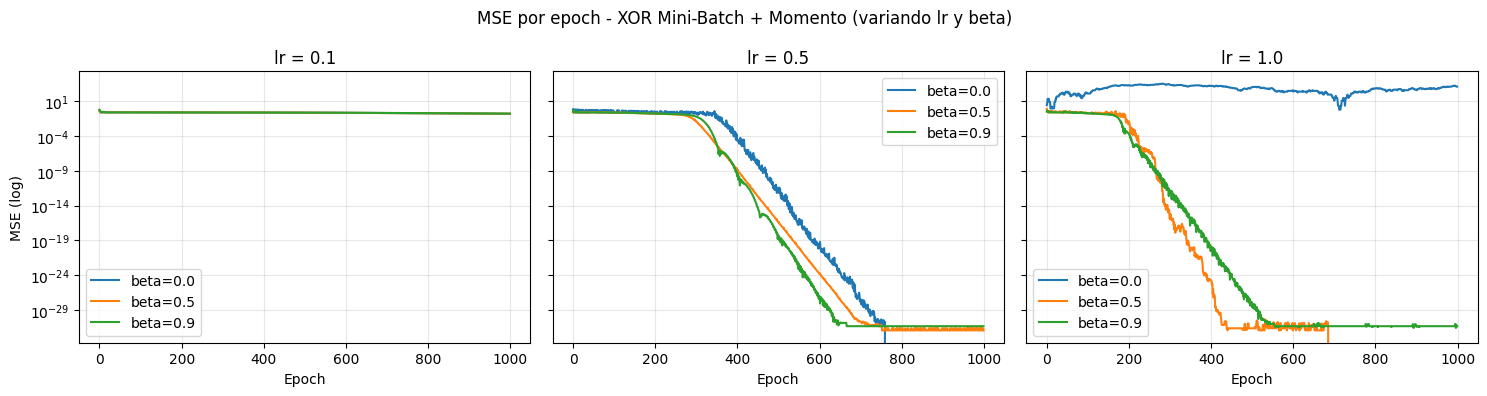

In [5]:
fig, axes = plt.subplots(1, len(lrs), figsize=(15, 4), sharey=True)
for ax, lr in zip(axes, lrs):
    for beta in betas:
        ax.plot(resultados[(lr, beta)], label=f"beta={beta}")
    ax.set_title(f"lr = {lr}")
    ax.set_xlabel("Epoch")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("MSE (log)")
fig.suptitle("MSE por epoch - XOR Mini-Batch + Momento (variando lr y beta)")
plt.tight_layout()
plt.show()

**Lectura del barrido:**
- Con $lr$ chico, subir $\beta$ acelera la convergencia (el momento acumula dirección y avanza más rápido).
- Con $lr$ grande, un $\beta$ alto puede sobre-acelerar y producir oscilaciones o inestabilidad.
- El mejor punto es un compromiso entre $\eta$ y $\beta$: momento suficiente para acelerar sin desestabilizar.

## Entrenamiento final con la mejor combinación

Elegimos automáticamente la combinación $(\eta, \beta)$ con menor MSE final y verificamos las predicciones.

In [6]:
mejor = min(resultados, key=lambda k: resultados[k][-1])
lr_best, beta_best = mejor
print(f"Mejor combinacion -> lr={lr_best}, beta={beta_best}, MSE={resultados[mejor][-1]:.6e}")

hist, (W1, b1, W2, b2) = entrenar(lr_best, beta_best, batch_size=2, epochs=epochs)
print(f"MSE inicial: {hist[0]:.5f}")
print(f"MSE final:   {hist[-1]:.6e}")

Mejor combinacion -> lr=0.5, beta=0.0, MSE=0.000000e+00
MSE inicial: 0.67361
MSE final:   0.000000e+00


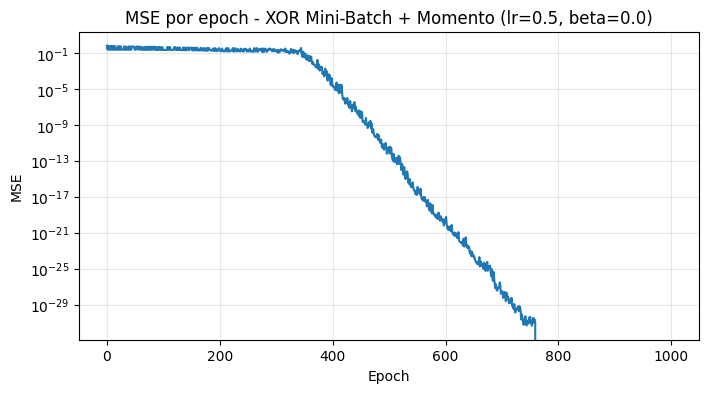

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(f"MSE por epoch - XOR Mini-Batch + Momento (lr={lr_best}, beta={beta_best})")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

## Predicciones - verificación

La salida no tiene activación, así que $\hat{y}$ es continuo. Redondeamos para obtener la clase y comparamos con la tabla XOR esperada $[0, 1, 1, 0]$.

In [8]:
preds, _ = forward(X, W1, b1, W2, b2)
print(f"{'X1':>3} {'X2':>3} | {'y_real':>7} {'y_hat':>9} {'pred':>5}")
print('-' * 34)
for i in range(len(X)):
    y_hat = preds[i]
    pred = int(round(y_hat))
    print(f"{int(X[i,0]):>3} {int(X[i,1]):>3} | {int(y[i]):>7} {y_hat:>9.4f} {pred:>5}")

 X1  X2 |  y_real     y_hat  pred
----------------------------------
  0   0 |       0    0.0000     0
  0   1 |       1    1.0000     1
  1   0 |       1    1.0000     1
  1   1 |       0    0.0000     0
